In [5]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


## Load Data

In [ ]:
sensor_info = {
    'PS1': 6000, 'PS2': 6000, 'PS3': 6000, 'PS4': 6000, 'PS5': 6000, 'PS6': 6000,  # Pressure sensors (100 Hz)
    'EPS1': 6000,  # Motor power sensor (100 Hz)
    'FS1': 600, 'FS2': 600,  # Volume flow sensors (10 Hz)
    'TS1': 60, 'TS2': 60, 'TS3': 60, 'TS4': 60,  # Temperature sensors (1 Hz)
    'VS1': 60,  # Vibration sensor (1 Hz)
    'SE': 60,  # Efficiency factor (1 Hz)
    'CE': 60,  # Virtual cooling efficiency sensor (1 Hz)
    'CP': 60   # Virtual cooling power sensor (1 Hz)
}

#Replace with your full directory of the "dataset" folder.
DATASET_PATH = "G:\Work\Predictive_Maintainence\code\Predictive_Maintenance_Device\dataset"
file_path_template = f"{DATASET_PATH}"+"/{}.txt"

data_frames = []

for sensor, num_attributes in sensor_info.items():
    file_path = file_path_template.format(sensor)
    column_names = [f"{sensor}_{i+1}" for i in range(num_attributes)]
    df_sensor = pd.read_csv(file_path, delimiter='\t', header=None, names=column_names)
    data_frames.append(df_sensor)

df_final = pd.concat(data_frames, axis=1)
target_cols = ["cool_cond", "valve_cond", "pump_leak", "hyd_accum", "stable_flag"]
profile = pd.read_csv(f"{DATASET_PATH}"+"/profile.txt", delimiter="\t", header=None, names=target_cols)

df_final = pd.concat([df_final, profile], axis=1)

## Shape

In [10]:
df_final.shape

(2205, 43685)

## Checking Null Values

In [11]:
print(df_final.isnull().sum())

PS1_1          0
PS1_2          0
PS1_3          0
PS1_4          0
PS1_5          0
              ..
cool_cond      0
valve_cond     0
pump_leak      0
hyd_accum      0
stable_flag    0
Length: 43685, dtype: int64


## **Step 3: Feature Engineering**

In [6]:
X = df_final.drop(columns=target_cols)
y = df_final[target_cols]

### **Removing Low-Variance Features**
selector = VarianceThreshold(threshold=0.05)
X_selected = selector.fit_transform(X)
selected_columns = X.columns[selector.get_support()]
df_reduced = pd.DataFrame(X_selected, columns=selected_columns)

# Adding target variables back
df_reduced = pd.concat([df_reduced, y], axis=1)
print("After variance threshold:", df_reduced.shape)

### **Handling Skewed Features using PowerTransformer**
from scipy.stats import skew

skewed_features = df_reduced.drop(columns=target_cols).apply(lambda x: skew(x)).sort_values(ascending=False)
high_skew = skewed_features[abs(skewed_features) > 1].index

pt = PowerTransformer(method='yeo-johnson')  # Works for both positive & negative values
df_reduced[high_skew] = pt.fit_transform(df_reduced[high_skew])

### **Standardization**
scaler = StandardScaler()
df_reduced.iloc[:, :-len(target_cols)] = scaler.fit_transform(df_reduced.drop(columns=target_cols))

print("Feature engineering complete!")

After variance threshold: (2205, 39741)
Feature engineering complete!


## **Step 4: Apply PCA**


In [7]:
X = df_reduced.drop(columns=target_cols)
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
df_pca = pd.concat([df_pca, y], axis=1)

print("Final dataset shape after PCA:", df_pca.shape)

Final dataset shape after PCA: (2205, 9)


## **Step 5: Model Training & Comparison**


In [11]:
model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, verbose=-1, random_state=42),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=500, random_state=42)
}

# Store results


In [12]:
results = {"With PCA": {}, "Without PCA": {}}

for dataset_name, df in [("With PCA", df_pca), ("Without PCA", df_reduced)]:
    results[dataset_name] = {}

    for target in target_cols:
        X = df.drop(columns=target_cols)
        y = df[target]

        # Check if the target variable is binary or multi-class
        unique_classes = np.unique(y)
        is_binary = len(unique_classes) == 2

        # Encode labels only if necessary (XGBoost requires sequential integer labels)
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)  # Convert classes (e.g., [3, 20, 100] -> [0, 1, 2])

        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

        print(f"Processing Target: {target} | Dataset: {dataset_name} | Classes: {unique_classes} -> {label_encoder.classes_}")

        results[dataset_name][target] = {}

        for model_name, model in models.items():
            print(f"Training Model: {model_name} for Target: {target} on {dataset_name}")

            model.fit(X_train, y_train)

            model_filename = os.path.join(model_dir, f"{model_name}_{dataset_name}_{target}.pkl")
            with open(model_filename, "wb") as model_file:
                pickle.dump(model, model_file)

            y_pred = model.predict(X_test)

            # Handle probability predictions safely
            y_proba = None
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test)
                if is_binary:
                    y_proba = y_proba[:, 1]  # Take probability for positive class

            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="weighted")

            # Compute ROC-AUC safely
            roc_auc = None
            if y_proba is not None:
                if is_binary:
                    roc_auc = roc_auc_score(y_test, y_proba)
                else:
                    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")

            results[dataset_name][target][model_name] = {
                "Accuracy": accuracy,
                "F1-Score": f1,
                "ROC-AUC": roc_auc
            }

            print(f"Model: {model_name} | Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f} | ROC-AUC: {roc_auc}")

Processing Target: cool_cond | Dataset: With PCA | Classes: [  3  20 100] -> [  3  20 100]
Training Model: RandomForest for Target: cool_cond on With PCA
Model: RandomForest | Accuracy: 0.9841 | F1-Score: 0.9841 | ROC-AUC: 0.9978571172670749
Training Model: LightGBM for Target: cool_cond on With PCA
Model: LightGBM | Accuracy: 0.9932 | F1-Score: 0.9932 | ROC-AUC: 0.9994514610476423
Training Model: NaiveBayes for Target: cool_cond on With PCA
Model: NaiveBayes | Accuracy: 0.9773 | F1-Score: 0.9774 | ROC-AUC: 0.9958447426283934
Training Model: KNN for Target: cool_cond on With PCA
Model: KNN | Accuracy: 0.9864 | F1-Score: 0.9864 | ROC-AUC: 0.9964962525020021
Training Model: GradientBoosting for Target: cool_cond on With PCA
Model: GradientBoosting | Accuracy: 0.9841 | F1-Score: 0.9841 | ROC-AUC: 0.9984240106911114
Training Model: SVM for Target: cool_cond on With PCA
Model: SVM | Accuracy: 0.9773 | F1-Score: 0.9773 | ROC-AUC: 0.9977131311419991
Training Model: LogisticRegression for Targ

# Results (Evalution)


In [13]:
df_results = []

for dataset, targets in results.items():
    for target, models in targets.items():
        for model, scores in models.items():
            df_results.append([dataset, target, model, scores["Accuracy"], scores["F1-Score"], scores["ROC-AUC"]])

df_results = pd.DataFrame(df_results, columns=["Dataset", "Target", "Model", "Accuracy", "F1-Score", "ROC-AUC"])

In [17]:
df_results

,Dataset,Target,Model,Accuracy,F1-Score,ROC-AUC
0,With PCA,cool_cond,RandomForest,0.984127,0.984111,0.997857
1,With PCA,cool_cond,LightGBM,0.993197,0.993197,0.999451
2,With PCA,cool_cond,NaiveBayes,0.977324,0.977362,0.995845
3,With PCA,cool_cond,KNN,0.986395,0.986394,0.996496
4,With PCA,cool_cond,GradientBoosting,0.984127,0.984111,0.998424
...,...,...,...,...,...,...
65,Without PCA,stable_flag,NaiveBayes,0.807256,0.811994,0.850274
66,Without PCA,stable_flag,KNN,0.975057,0.974909,0.988491
67,Without PCA,stable_flag,GradientBoosting,0.970522,0.970498,0.993149
68,Without PCA,stable_flag,SVM,0.931973,0.931255,0.984700


In [15]:
df_results.to_csv("output.csv")

In [20]:
df_without = df_results[df_results['Dataset'] == "Without PCA"]

In [22]:
df_with = df_results[df_results['Dataset'] == "With PCA"]

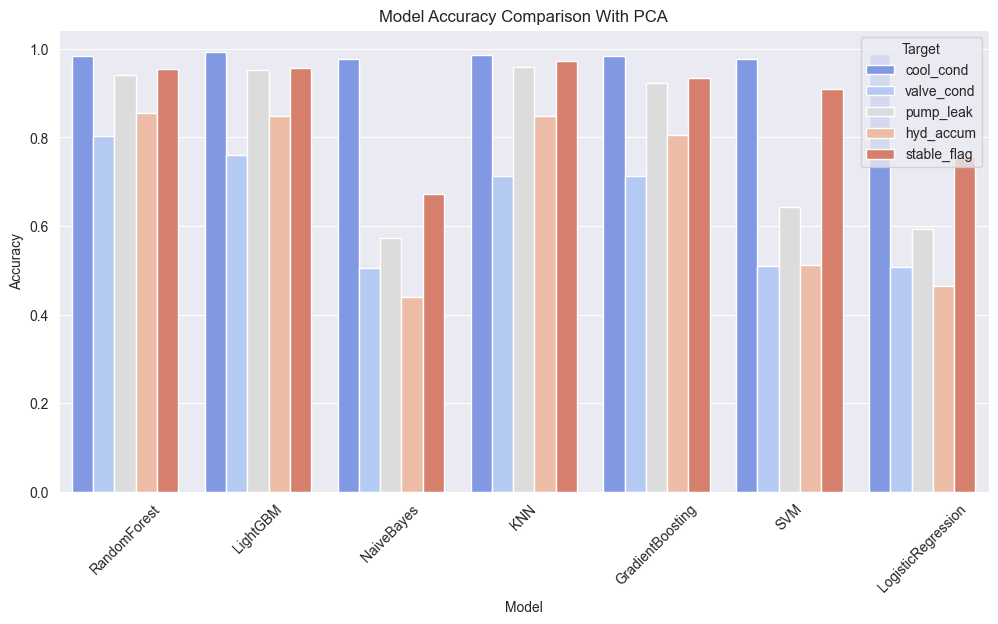

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_with, x="Model", y="Accuracy", hue="Target", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison With PCA")
plt.show()

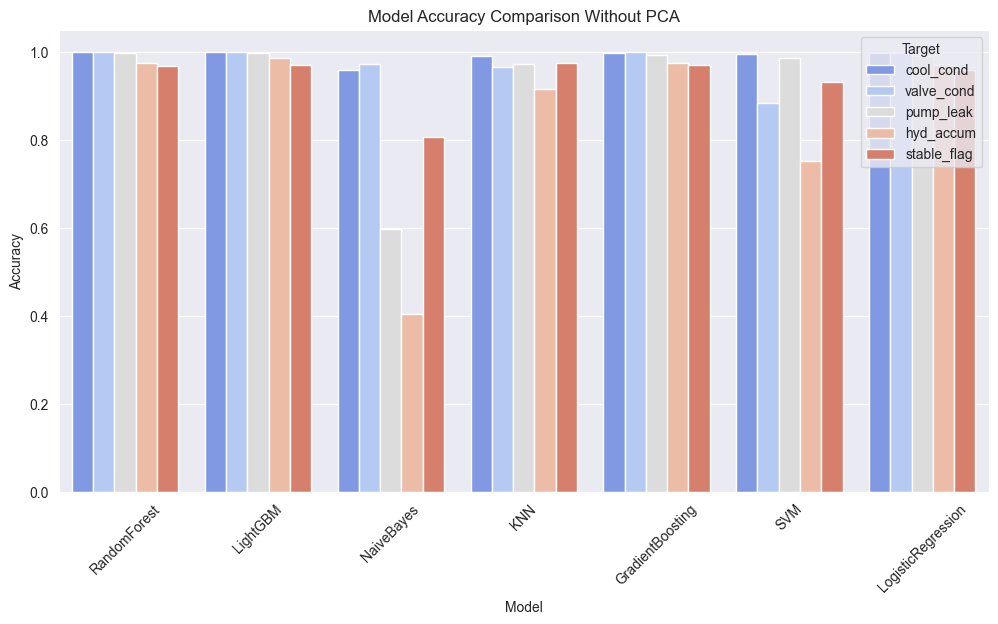

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_without, x="Model", y="Accuracy", hue="Target", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison Without PCA")
plt.show()

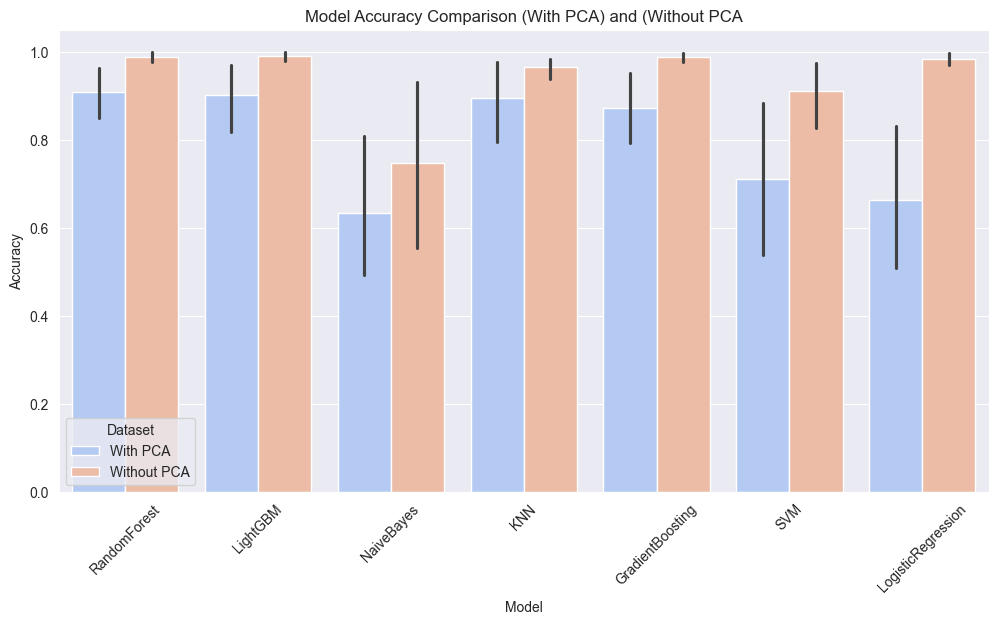

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="Model", y="Accuracy", hue="Dataset", palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison (With PCA) and (Without PCA")
plt.show()